In [1]:
import pandas as pd

df = pd.read_csv("data/heart.csv")

print(df.head())
print(df.info())
print(df.describe())

   id  age     sex    dataset               cp  trestbps   chol    fbs  \
0   1   63    Male  Cleveland   typical angina     145.0  233.0   True   
1   2   67    Male  Cleveland     asymptomatic     160.0  286.0  False   
2   3   67    Male  Cleveland     asymptomatic     120.0  229.0  False   
3   4   37    Male  Cleveland      non-anginal     130.0  250.0  False   
4   5   41  Female  Cleveland  atypical angina     130.0  204.0  False   

          restecg  thalch  exang  oldpeak        slope   ca  \
0  lv hypertrophy   150.0  False      2.3  downsloping  0.0   
1  lv hypertrophy   108.0   True      1.5         flat  3.0   
2  lv hypertrophy   129.0   True      2.6         flat  2.0   
3          normal   187.0  False      3.5  downsloping  0.0   
4  lv hypertrophy   172.0  False      1.4    upsloping  0.0   

                thal  num  
0       fixed defect    0  
1             normal    2  
2  reversable defect    1  
3             normal    0  
4             normal    0  
<class '

In [2]:
df['target'] = df['num'].apply(lambda x: 1 if x > 0 else 0)
df.drop('num', axis=1, inplace=True)

print(df['target'].value_counts())

target
1    509
0    411
Name: count, dtype: int64


In [3]:
df.isnull().sum()

id            0
age           0
sex           0
dataset       0
cp            0
trestbps     59
chol         30
fbs          90
restecg       2
thalch       55
exang        55
oldpeak      62
slope       309
ca          611
thal        486
target        0
dtype: int64

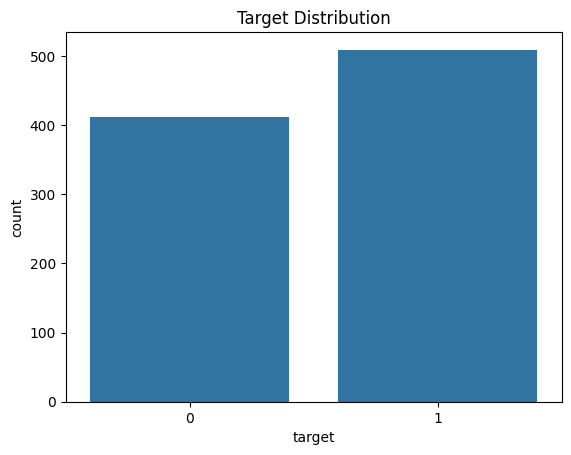

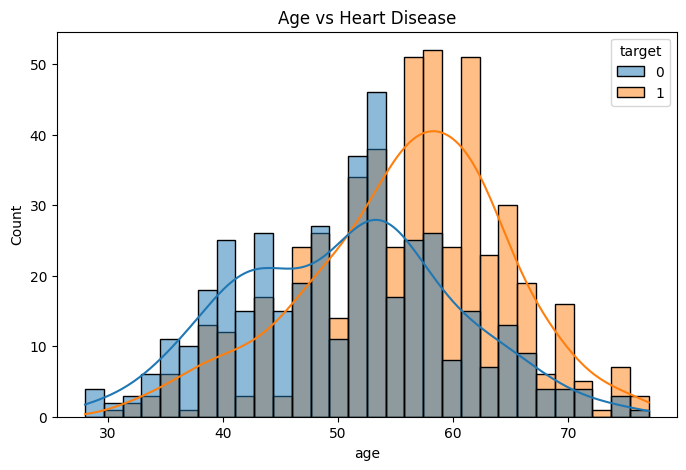

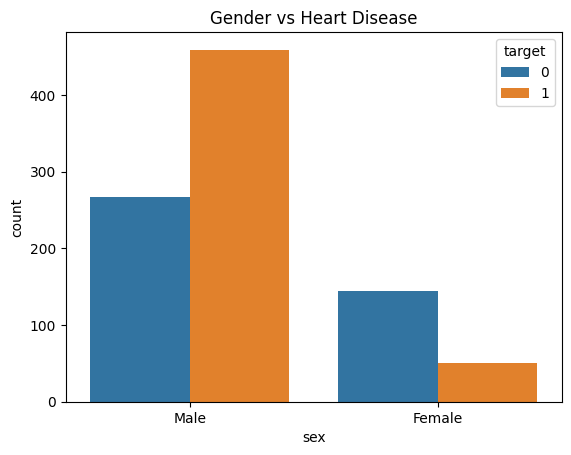

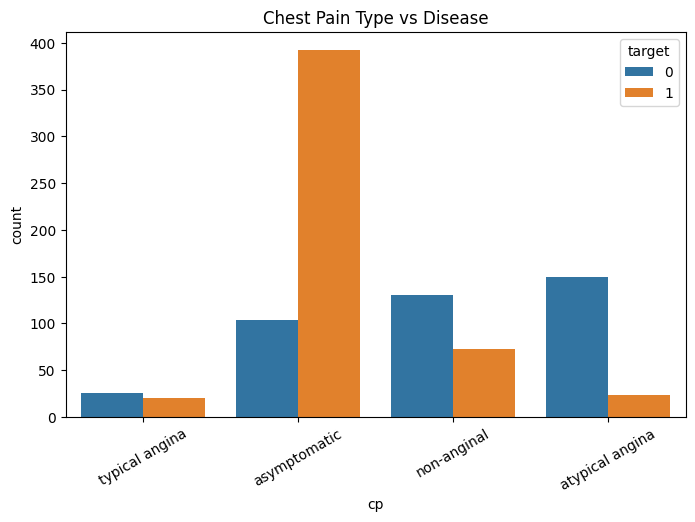

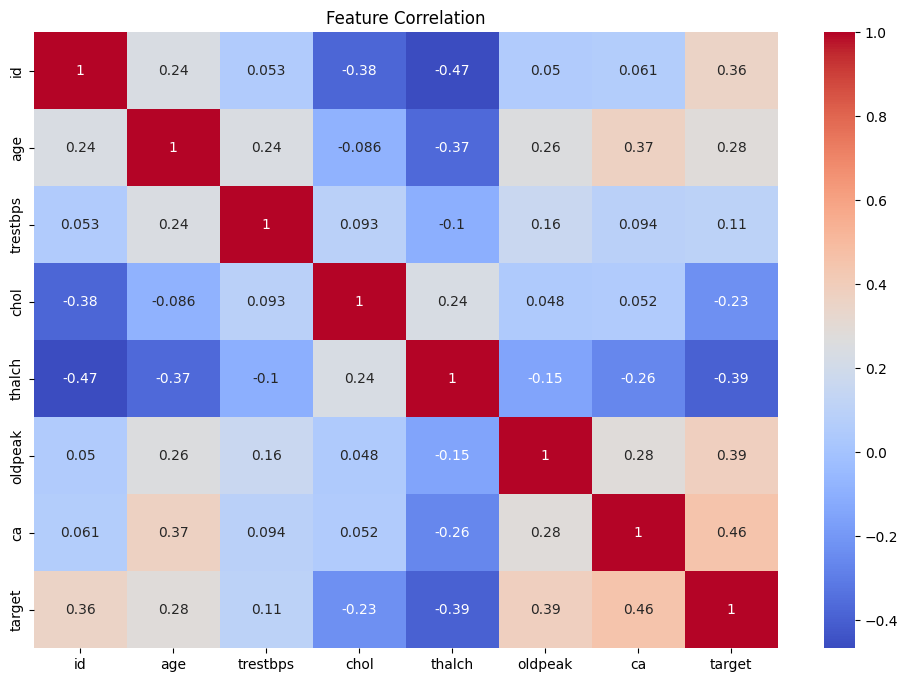

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Target distribution
sns.countplot(x='target', data=df)
plt.title("Target Distribution")
plt.show()

# 2. Age vs Heart Disease
plt.figure(figsize=(8,5))
sns.histplot(data=df, x='age', hue='target', bins=30, kde=True)
plt.title("Age vs Heart Disease")
plt.show()

# 3. Sex vs Target
sns.countplot(x='sex', hue='target', data=df)
plt.title("Gender vs Heart Disease")
plt.show()

# 4. Chest Pain vs Target
plt.figure(figsize=(8,5))
sns.countplot(x='cp', hue='target', data=df)
plt.xticks(rotation=30)
plt.title("Chest Pain Type vs Disease")
plt.show()

# 5. Correlation Heatmap (VERY IMPORTANT 🔥)
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Feature Correlation")
plt.show()

In [7]:
# Fill numerical columns
num_cols = df.select_dtypes(include=['float64', 'int64']).columns

for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

# Fill categorical columns
cat_cols = cat_cols = df.select_dtypes(include=['object', 'string']).columns

for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

In [8]:
print(df.isnull().sum())
print(df.dtypes)
print(df.shape)

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalch      0
exang       0
oldpeak     0
target      0
dtype: int64
age           int64
sex             str
cp              str
trestbps    float64
chol        float64
fbs          object
restecg         str
thalch      float64
exang        object
oldpeak     float64
target        int64
dtype: object
(920, 11)


In [10]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

cat_cols = ['sex', 'cp', 'restecg', 'fbs', 'exang']

for col in cat_cols:
    df[col] = le.fit_transform(df[col])

In [11]:
print(df.dtypes)

age           int64
sex           int64
cp            int64
trestbps    float64
chol        float64
fbs           int64
restecg       int64
thalch      float64
exang         int64
oldpeak     float64
target        int64
dtype: object
